## 2차 프로젝트(실험) 요약 및 회고
#### 참고 1차 실험 내용
- https://github.com/wide-bridge/AIFFEL_quest_eng/blob/main/NLP/NLP02/chatbot_01.ipynb
### 2차 프로젝트 요약
- 본 프로젝트는 Transformer를 이용하여, 사용자의 질문에 대하여 챗봇이 답변(상담)하는 챗봇임.
- 주어진 데이터를 파악하고, 정제하고, 토큰화하고 증강한 후 Embedding 벡터 Transformer에 입력할 수 있게 준비하여
- positional_encoding 함수와 MultiHeadAttention, FNN, EncoderLayer, Encoder, DecoderLayer, Decoder 등의 클래스를 활용하여 
- Transformer 클래스 팩을 조립하였음
- 이번 2차 프로젝트는 1차 프로젝트 후에 C2 팀원들과 토의 중에 발견된 문제를 찾아서 수정하였음
- 데이터 증강은 기존 (확률적 치환 + topn 랜덤) + 강진규님 방식(문장당 1토큰 치환 시도)를 2차에 걸처 추가하여 데이터를 (23,000 -> 38,682) 대폭 증강
- 인코더와 디코더의 레이어를 3회 반복 수행(기존 1회 수행)
- 신기주님이 수행한 결과를 보면, Epoch를 200까지 늘려도 Train Loss와 Validation Loss가 지속적으로 감소하는 것이 발견됨에 따라 Epoch를 200으로 늘림
- 즉 앞 프로젝트 1과 다르게 Train/validation 데이터로 나누어, 조기종료 조건(Patience=10)을 넣었으나 200 Epoch 동안 조기종료가 발생하지 않음- - 
✅ Best model restored (by val_loss). best_val=2.2289 (best_epoch=197)
#### 첫번째 200 epoch
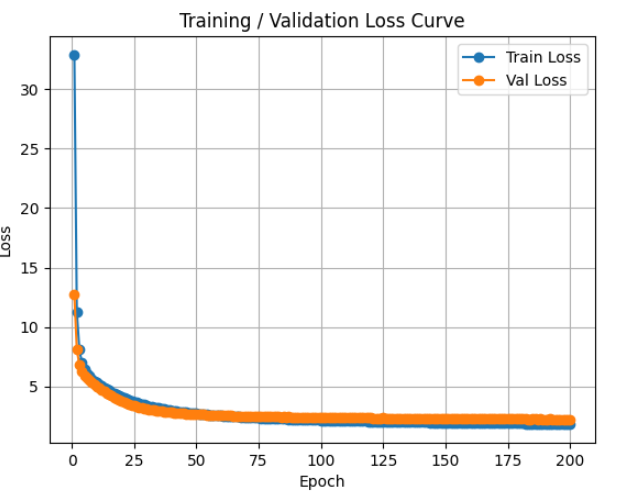
#### 두번째 100 epoch 실행
 - 조기 종료가 발생하지 않아 추가로 100 epoch 실행(Patience=10)함에 따라 추가로 27 Epoch에 조기 종료됨 
 - 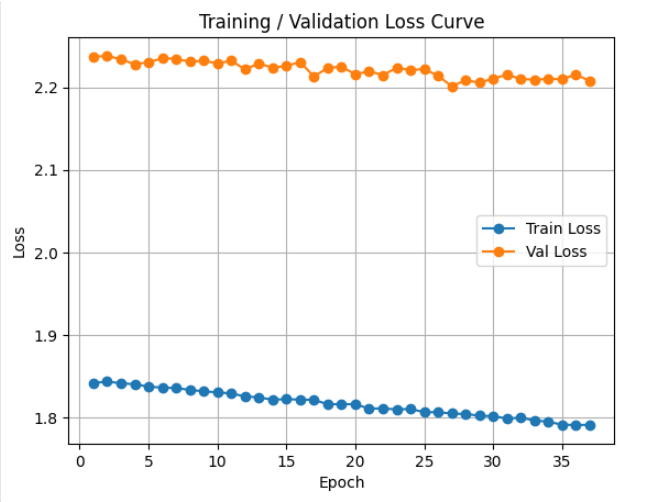 - ✅ Best model restored (by val_loss). best_val=2.2014 (best_epoch=27)
   
#### 출력 사례
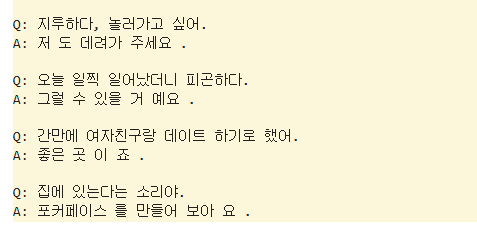
   

-성능 평가는 기본적으로 BLEU 지표를 사용하였으며,나본 Task가 챗봇 응답 생성이라는 점을 고려하여 ROUGE 지표도 함께 측정함
  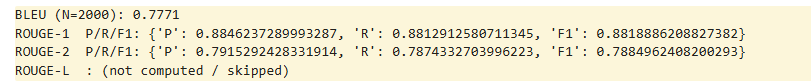
  
-  BLEU는 n-gram 겹침 정도를 기반으로 하는 평가 지표로, 본 실험에서는 BLEU 점수가 약 0.77 수준으로 나타났음.
-  또한 ROUGE 지표를 함께 측정한 결과,
-  단어 unigram 겹침을 나타내는 ROUGE-1 재현율은 0.8813으로 예측 문장과 정답 문장의 단어 중 약 88% 정도가 겹치는 것으로 나타났다.
-  연속된 두 단어의 겹침을 평가하는 ROUGE-2 재현율은 0.7874로 나타났으며, 이는 문장 구조 측면에서도 높은 유사도가 있음을 의미한다.
-  (예: 정답 "오늘 날씨 좋다", 예측 "오늘 날씨 좋다" → 2-gram: "오늘 날씨", "날씨 좋다")
- 단어 unigram 겹침을 나타내는 ROUGE-1 재현율 0.8813으로 단어의 88% 정도가 정답과 겹침(ex 정답 오늘 날씨 좋다, 예측 오늘 날씨 좋다)
-  ROUGE-L은 Longest Common Subsequence 기반 지표로 계산 비용이 크기 때문에 본 실험에서는 compute_rouge_l=False 설정을 사용하여 계산을 생략하였다.

- 다만 현재 BLEU와 ROUGE 점수가 매우 높은 수준으로 나타났는데, 이는 챗봇 데이터의 특성상 짧고 반복적인 문장이 많기 때문일 수도 있지만,
- 학습 데이터와 평가 데이터 간의 중복(데이터 누수)이 존재할 가능성도 있다.
  
- 따라서 향후 실험에서는 train / validation / test dataset을 명확히 분리하여 데이터 누수가 발생하지 않는 평가 체계를 구축할 예정이다.
- 아울러 BLEU와 ROUGE를 측정하는 과정에서 ERROR가 많았다.
- 다음번에 같은 실수를 하지 않기 위하여 ERROR 코드를 지우지 않고, 기록에 남겼다.
- 특히 ERROR의 원인을 파악하는 코드가 해결에 주효했다. 이를 함께 남긴다.

    
- 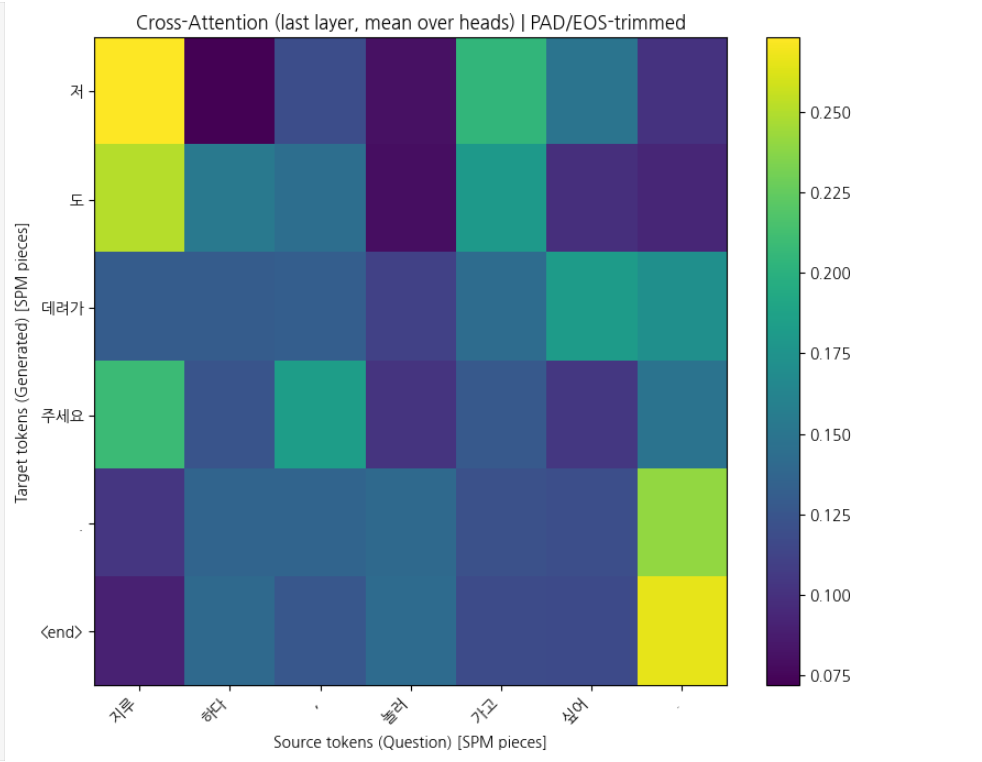음

#
## 프로젝트 회고

- 
-1차 실험에 이어 2차 시험은 팀원들과 소통의 결과
- . 1차 실험은 기대와 다른 결과가 나와 무척 실망했다.
- 하지만 팀원들과 소통하는 과정에서 내가 생각하지 못한 것들이 많다는 것을 발견했다.
- 1차 실험은 기대도 컸지만, 전체를 온전히 판단하기 전에 먼저 겁을 먹었다.
- 그런데 팀원들이 진행한 과정을 공유하면서, 내 실험에서 놓친 것들을 발견하고 아이디어를 보강했다..
-이번 팀 프로젝트는 AI는 프로젝트는 혼자가면 빨리갈 수도 없고, 제대로 갈 수도 없다는 것을 발견한 귀중한 경험이었음.

## Task 확인 및 프로젝트 방향
---
#### Task 확인 : Transformer를 이용한 Chatbot 만들기
---
### Project Process
- step 0. 라이브러리 및 기본 설정
- step 1. 데이터 다운로드
- step 2. 데이터 정제
- step 3. 데이터 토큰화
- step 4. 데이터 증강
- step 5. 데이터 벡터화
- step 6. Transformer Pack 구성 및 모델 훈련
- step 7. 성능 측정

### Step 0. 라이브러리 및 기본 설정

In [1]:
# ============================================================
# [STEP 0 - CELL 1] Imports & Global Config
# ============================================================

import numpy as np
import pandas as pd
import torch
import sentencepiece as spm
from nltk.translate.bleu_score import sentence_bleu
from nltk.translate.bleu_score import SmoothingFunction
from konlpy.tag import Mecab
import gensim

import re
import os
import random
import math

from tqdm.notebook import tqdm
import matplotlib.pyplot as plt

print(torch.__version__)

# 재현성
SEED = 42
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)
torch.cuda.manual_seed_all(SEED)

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("DEVICE:", device)

# # 최대 길이 (토큰 기준) - 뒤에서 다시 조정함
MAX_LEN = 40 

# Special tokens (이전 노트북의 SPM id 관례(0~3)와 맞추기 위해 이렇게 둡니다)
PAD_TOKEN = "<pad>"
BOS_TOKEN = "<start>"
EOS_TOKEN = "<end>"
UNK_TOKEN = "<unk>"

PAD_ID = 0
BOS_ID = 1
EOS_ID = 2
UNK_ID = 3

2.8.0+cu126
DEVICE: cuda


### Step 1. 데이터 다운로드
- 압축해제 → questions, answers

In [3]:
# ============================================================
# [STEP 1 - CELL 1] Unzip Chatbot_data.zip
# ============================================================

import zipfile
from pathlib import Path

zip_path = Path(r"D:\PyProject\AIFFEL_AI\LLM\NLP\NLP02\data\Chatbot_data.zip")
extract_dir = zip_path.parent / "Chatbot_data_unzipped"
extract_dir.mkdir(parents=True, exist_ok=True)

with zipfile.ZipFile(zip_path, "r") as zf:
    zf.extractall(extract_dir)

print("Extracted to:", extract_dir)

Extracted to: D:\PyProject\AIFFEL_AI\LLM\NLP\NLP02\data\Chatbot_data_unzipped


In [4]:
# ============================================================
# [STEP 1 - CELL 2] Load ChatbotData.csv -> questions, answers
# ============================================================

# 보통 파일명이 ChatbotData.csv 인 경우가 많습니다(프로젝트 표준).
# 혹시 이름이 다르면 extract_dir 아래 CSV를 자동 탐색합니다.

csv_files = list(extract_dir.rglob("*.csv"))
assert len(csv_files) > 0, f"CSV 파일을 찾지 못했습니다: {extract_dir}"

csv_path = csv_files[0]
print("Using CSV:", csv_path)

df = pd.read_csv(csv_path)
print(df.head())
print(df.columns)

# 일반적으로 Q/A 컬럼이 존재합니다.
# (예외 대비) 컬럼명이 다르면 아래 후보에서 찾습니다.
q_col_candidates = ["Q", "question", "questions", "Question"]
a_col_candidates = ["A", "answer", "answers", "Answer"]

q_col = next((c for c in q_col_candidates if c in df.columns), None)
a_col = next((c for c in a_col_candidates if c in df.columns), None)

assert q_col is not None, f"질문 컬럼을 찾지 못했습니다. columns={df.columns.tolist()}"
assert a_col is not None, f"답변 컬럼을 찾지 못했습니다. columns={df.columns.tolist()}"

questions = df[q_col].astype(str).tolist()
answers   = df[a_col].astype(str).tolist()

print("questions:", len(questions), "| answers:", len(answers))
print("Q sample:", questions[0])
print("A sample:", answers[0])

Using CSV: D:\PyProject\AIFFEL_AI\LLM\NLP\NLP02\data\Chatbot_data_unzipped\Chatbot_data-master\ChatbotData.csv
                 Q            A  label
0           12시 땡!   하루가 또 가네요.      0
1      1지망 학교 떨어졌어    위로해 드립니다.      0
2     3박4일 놀러가고 싶다  여행은 언제나 좋죠.      0
3  3박4일 정도 놀러가고 싶다  여행은 언제나 좋죠.      0
4          PPL 심하네   눈살이 찌푸려지죠.      0
Index(['Q', 'A', 'label'], dtype='str')
questions: 11823 | answers: 11823
Q sample: 12시 땡!
A sample: 하루가 또 가네요.


### Step 2. 데이터 정제 
- preprocess_sentence() 구현
- 영어는 소문자로, 영문/한글/숫자/주요 특수문자만 남기고 나머지 제거
- 특수문자 범위는 과하게 넓히지 않고, 대화에서 흔한 것 위주로 구성

In [8]:
# ============================================================
# [STEP 2 - CELL 1] preprocess_sentence()  (이전 노트북 이름 유지)
# ============================================================

def preprocess_sentence(sentence: str) -> str:
    """
    - 영문자는 소문자로 변환
    - 영문/한글/숫자/주요 특수문자만 허용, 나머지는 제거
    - 토크나이저가 문장부호 처리 가능하므로 문장부호 양옆 공백 추가 등은 생략
    """
    s = str(sentence).lower().strip()

    # 허용: 한글, 영문, 숫자, 공백, 그리고 주요 특수문자(대화 데이터에 흔한 것)
    # . , ? ! ~ % @ # & ( ) [ ] { } : ; ' " - _ + = / \ |
    s = re.sub(r"[^0-9a-zA-Z가-힣\s\.\,\?\!\~\%\@\#\&\(\)\[\]\{\}\:\;\'\"\-\_\+\=\/\\\|]", "", s)

    # 공백 정리
    s = re.sub(r"\s+", " ", s).strip()
    return s

print(preprocess_sentence("안녕?? HELLO@@@ 😊 ㅎㅎㅎ"))

안녕?? hello@@@


### Step 3. 데이터 토큰화
#### 3.1 Tokenizer getter(Mecab -> Okt fallback)
- build_corpus() + Windows Mecab 대처
- KoNLPy 문서에서 konlpy.tag.Mecab()은 Windows 미지원
- 대처 옵션: (권장) WSL2(우분투)에서 KoNLPy Mecab 사용
- Windows 네이티브에서 mecab-ko-msvc 설치(다만 KoNLPy Mecab이 “공식 지원”은 아니라서 환경마다 편차가 있음)
- 당장 진행이 목표면 Okt().morphs로 fallback(성능은 Mecab이 더 좋을 때가 많지만 파이프라인은 돌아감)
- 아래 코드는 가능하면 Mecab, 실패하면 Okt로 전환

In [10]:
# ============================================================
# [STEP 3 - CELL 1] Tokenizer getter (Mecab -> Okt fallback)
# ============================================================

def get_morphs():
    """
    반환값: callable(str) -> List[str]
    우선순위:
      1) KoNLPy Mecab (WSL/리눅스 환경에서 주로 성공)  :contentReference[oaicite:5]{index=5}
      2) KoNLPy Okt fallback
    """
    try:
        from konlpy.tag import Mecab
        mecab = Mecab()  # Windows에선 일반적으로 여기서 실패 가능 :contentReference[oaicite:6]{index=6}
        print("Tokenizer: KoNLPy Mecab")
        return mecab.morphs
    except Exception as e:
        print("KoNLPy Mecab 사용 불가 -> Okt로 대체합니다.")
        print("원인(참고):", repr(e))
        from konlpy.tag import Okt
        okt = Okt()
        print("Tokenizer: KoNLPy Okt")
        return okt.morphs

morphs = get_morphs()
print(morphs("지루하다 놀러가고 싶어"))

KoNLPy Mecab 사용 불가 -> Okt로 대체합니다.
원인(참고): Exception('The MeCab dictionary does not exist at "/usr/local/lib/mecab/dic/mecab-ko-dic". Is the dictionary correctly installed?\nYou can also try entering the dictionary path when initializing the Mecab class: "Mecab(\'/some/dic/path\')"')
Tokenizer: KoNLPy Okt
['지루하다', '놀러', '가고', '싶어']


#### 3.2 build_corpus() 구현 + 기존 make_corpus() 이름 유지
- src/tgt 각각 정제+토큰화
- 길이 제한 초과 제거
- 중복 제거(소스는 소스대로, 타겟은 타겟대로)
- 쌍이 흐트러지지 않게 동일 인덱스를 유지하며 필터링
#### ✅ 구현 방식:
- 소스/타겟 각각 “허용 여부(keep mask)”를 만들고, 둘 다 keep인 것만 남김
- 중복 체크는 각각 seen_src, seen_tgt로 관리

In [12]:
# ============================================================
# [STEP 3 - CELL 2] make_corpus() 이름 유지
# ============================================================

def make_corpus(src_sentences, tgt_sentences, tokenizer_func, max_len=40):
    """
    반환: (src_corpus, tgt_corpus)
    - src/tgt 각각 preprocess_sentence 후 tokenizer_func 적용
    - 토큰 길이 >= max_len 인 문장 제외 (요구사항: 일정 길이 이상 제외)
    - 중복 문장 제외 (src는 src대로, tgt는 tgt대로)
    - 쌍이 흐트러지지 않도록 keep mask를 적용
    """
    assert len(src_sentences) == len(tgt_sentences)

    src_corpus = []
    tgt_corpus = []

    seen_src = set()
    seen_tgt = set()

    for s, t in zip(src_sentences, tgt_sentences):
        s_clean = preprocess_sentence(s)
        t_clean = preprocess_sentence(t)

        s_tokens = tokenizer_func(s_clean)
        t_tokens = tokenizer_func(t_clean)

        # 길이 제한 (>= max_len 제외)
        if len(s_tokens) >= max_len or len(t_tokens) >= max_len:
            continue

        # 중복 제거 (각각 따로)
        s_key = " ".join(s_tokens)
        t_key = " ".join(t_tokens)

        if s_key in seen_src:
            continue
        if t_key in seen_tgt:
            continue

        seen_src.add(s_key)
        seen_tgt.add(t_key)

        src_corpus.append(s_tokens)
        tgt_corpus.append(t_tokens)

    return src_corpus, tgt_corpus

In [14]:
# ============================================================
# [STEP 3 - CELL 3] build_corpus() (프로젝트 요구 이름 추가 제공)
# - 내부적으로 make_corpus를 호출하여 "기존 이름 유지" + "과제 요구 충족"
# ============================================================

def build_corpus(src_sentences, tgt_sentences, tokenize_func, max_len=40):
    return make_corpus(src_sentences, tgt_sentences, tokenize_func, max_len=max_len)

que_corpus, ans_corpus = build_corpus(questions, answers, morphs, max_len=MAX_LEN)

print("que_corpus:", len(que_corpus), "ans_corpus:", len(ans_corpus))
print("Q tokens sample:", que_corpus[0])
print("A tokens sample:", ans_corpus[0])

que_corpus: 7701 ans_corpus: 7701
Q tokens sample: ['12시', '땡', '!']
A tokens sample: ['하루', '가', '또', '가네요', '.']


### Step 4. Augmentation — Word2Vec + lexical_sub()
- Kyubyong/wordvectors에서 Korean(w) Word2Vec를 받아 ko.bin 확보
- gensim으로 로드해서 lexical substitution 적용
- !pip install gensim

In [16]:
# ============================================================
# [STEP 4 - CELL 1] Load or Train Word2Vec + Safe Sample Check
# - 변수명/흐름: (que_corpus, ans_corpus, SEED) 기준 유지
# - 김진규님 방식 추가: (1) KeyedVectors 로드 옵션, (2) 안전 샘플 체크
# ============================================================
# pip install gensim tqdm  (안 되어 있으면 설치)

import os
import random
from gensim.models import Word2Vec
from gensim.models import KeyedVectors

# Step3에서 생성된 토큰 코퍼스 사용
sentences = que_corpus + ans_corpus

# (선택) 사전학습 KeyedVectors(.bin) 경로가 있으면 우선 로드
# - 동료의 ko_converted.bin을 그대로 쓰고 싶으면 아래 경로만 맞추세요.
PRETRAINED_BIN = "ko_converted.bin"  # 예: r"D:\PyProject\...\ko_converted.bin" 로 바꿔도 됨
USE_PRETRAINED = os.path.exists(PRETRAINED_BIN)

if USE_PRETRAINED:
    wv = KeyedVectors.load_word2vec_format(PRETRAINED_BIN, binary=True)
    print("✅ Pretrained KeyedVectors loaded:", PRETRAINED_BIN)
    print("vocab size:", len(wv))
else:
    # 로컬 Word2Vec 학습 (과제용 빠른 세팅) - 선생님 코드 유지
    w2v_model = Word2Vec(
        sentences=sentences,
        vector_size=200,
        window=5,
        min_count=1,   # ✅ 1로 설정 (vocab 누락 방지)
        workers=4,
        sg=1,          # skip-gram
        epochs=20,
        seed=SEED
    )
    wv = w2v_model.wv
    print("✅ Local Word2Vec trained.")
    print("vocab size:", len(wv.key_to_index))

# --- 안전한 sample similar 출력 ---
if sentences and len(sentences[0]) > 0:
    tok0 = sentences[0][0]
    if tok0 in wv:
        print("sample similar:", tok0, "=>", wv.most_similar(tok0, topn=5))
    else:
        any_tok = next(iter(wv.key_to_index.keys())) if hasattr(wv, "key_to_index") else next(iter(wv.index_to_key))
        print("sample similar:", any_tok, "=>", wv.most_similar(any_tok, topn=5))
else:
    print("No valid tokens for sample check.")

✅ Local Word2Vec trained.
vocab size: 11410
sample similar: 12시 => [('땡', 0.984163761138916), ('멋있게', 0.9833385944366455), ('받는대', 0.9808629751205444), ('스키장', 0.9800686836242676), ('0', 0.9797655940055847)]


In [17]:
# ============================================================
# [STEP 4 - CELL 2] lexical_sub() (이전 노트북 이름 유지)
# - 기존 방식(확률적 치환 + topn 랜덤) + 강진규님 방식(문장당 1토큰 치환 시도) 결합
# ============================================================

def lexical_sub(tokens, wv_model, replace_prob=0.3, topn=10, max_replacements=1, special_tokens=None):
    """
    tokens: List[str]
    - 문장 내 토큰을 유사어로 치환하는 증강
    - 안전 장치:
      1) wv에 존재하는 토큰만 후보
      2) special token 제외
      3) 기본적으로 문장당 max_replacements=1개만 치환(동료 방식의 안정성)
      4) 유사어 후보(topn) 중 랜덤 선택(선생님 방식의 다양성)
    """
    if tokens is None or len(tokens) == 0:
        return None

    if special_tokens is None:
        special_tokens = set()
    else:
        special_tokens = set(special_tokens)

    # 치환 가능한 토큰 인덱스 수집
    valid_idx = []
    for i, tok in enumerate(tokens):
        if tok in special_tokens:
            continue
        if tok in wv_model:
            valid_idx.append(i)

    if not valid_idx:
        return None

    new_tokens = tokens[:]
    replacements = 0

    # 무작위 순서로 돌면서 replace_prob에 따라 치환
    random.shuffle(valid_idx)
    for i in valid_idx:
        if replacements >= max_replacements:
            break
        if random.random() > replace_prob:
            continue

        tok = new_tokens[i]
        try:
            sims = wv_model.most_similar(tok, topn=topn)
        except Exception:
            continue

        cand = [w for (w, score) in sims if w != tok and (w not in special_tokens)]
        if not cand:
            continue

        new_tokens[i] = random.choice(cand)
        replacements += 1

    # 실제로 바뀐 게 없으면 None 처리(동료 방식: 증강 실패는 추가하지 않음)
    if new_tokens == tokens:
        return None

    return new_tokens


# quick test
print("Q[0]:", que_corpus[0])
print("Q[0] aug:", lexical_sub(que_corpus[0], wv, replace_prob=0.5, topn=10, max_replacements=1,
                              special_tokens=[PAD_TOKEN, BOS_TOKEN, EOS_TOKEN, UNK_TOKEN]))


Q[0]: ['12시', '땡', '!']
Q[0] aug: ['12시', '하시다니', '!']


In [20]:
# ============================================================
# [STEP 4 - CELL 3] Build augmented dataset (가변 증강 + 2회 시도)
# - 기본: 원본은 항상 포함
# - 추가:
#   1) (augQ1, oriA)
#   2) (oriQ, augA1)
#   3) (augQ1, augA1)
#   4) 2회차 증강(augQ2 / augA2)이 1회차와 다르면 추가
# ============================================================

from tqdm import tqdm  # ✅ notebook 말고 기본 tqdm 사용

aug_que_corpus = []
aug_ans_corpus = []

SPECIALS = [PAD_TOKEN, BOS_TOKEN, EOS_TOKEN, UNK_TOKEN]

for q, a in tqdm(zip(que_corpus, ans_corpus), total=len(que_corpus)):
    # 1) 원본 데이터 추가
    aug_que_corpus.append(q)
    aug_ans_corpus.append(a)

    # 2) 1회차 증강
    new_q1 = lexical_sub(q, wv, replace_prob=0.3, topn=10, max_replacements=1, special_tokens=SPECIALS)
    new_a1 = lexical_sub(a, wv, replace_prob=0.3, topn=10, max_replacements=1, special_tokens=SPECIALS)

    # (augQ1, oriA)
    if new_q1 is not None:
        aug_que_corpus.append(new_q1)
        aug_ans_corpus.append(a)

    # (oriQ, augA1)
    if new_a1 is not None:
        aug_que_corpus.append(q)
        aug_ans_corpus.append(new_a1)

    # (augQ1, augA1)
    if new_q1 is not None and new_a1 is not None:
        aug_que_corpus.append(new_q1)
        aug_ans_corpus.append(new_a1)

    # 3) 2회차 증강
    new_q2 = lexical_sub(q, wv, replace_prob=0.3, topn=10, max_replacements=1, special_tokens=SPECIALS)
    new_a2 = lexical_sub(a, wv, replace_prob=0.3, topn=10, max_replacements=1, special_tokens=SPECIALS)

    # 첫 번째 증강과 결과가 다를 때만 추가
    if new_q2 is not None and new_q2 != new_q1:
        aug_que_corpus.append(new_q2)
        aug_ans_corpus.append(a)

    if new_a2 is not None and new_a2 != new_a1:
        aug_que_corpus.append(q)
        aug_ans_corpus.append(new_a2)

print(f"증강 전 데이터 개수: {len(que_corpus)}")
print(f"증강 후 데이터 개수: {len(aug_que_corpus)}")

# 최종 결과 이름(선생님 스타일 유지)
que_corpus_3x = aug_que_corpus
ans_corpus_3x = aug_ans_corpus

assert len(que_corpus_3x) == len(ans_corpus_3x)
print("Final augmented size:", len(que_corpus_3x))

100%|████████████████████████████████████████████████████████████████████████████| 7701/7701 [00:06<00:00, 1223.55it/s]

증강 전 데이터 개수: 7701
증강 후 데이터 개수: 38682
Final augmented size: 38682


### Step 5. 데이터 벡터화 
- <start>/<end> 추가 + vocab 구축 + enc_train/dec_train
- ans_corpus에는 아직 <start>/<end>가 없으니 추가
- 챗봇은 src/tgt가 같은 언어 → vocab 공유가 유리
- 여기서는 word-level vocab(Mecab 토큰 기반)으로 진행

In [22]:
# ============================================================
# [STEP 5 - SINGLE PACK] ✅ SPM 기반 Vectorize + Train/Val Split + Dataset/DataLoader
# - "증강 데이터(que_corpus_3x, ans_corpus_3x)" 흐름이 절대 흐트러지지 않게 설계
# - 변수/함수명은 당신 스타일 유지: MAX_LEN, PAD/BOS/EOS/UNK, encode(), pad_to_maxlen(),
#   enc_train/dec_train, enc_val/dec_val, train_dataloader/val_dataloader, VOCAB_SIZE
# - SentencePiece(SPM) "제대로" 사용: pad/bos/eos/unk id를 0~3으로 고정
# ============================================================

# (필요시) !pip install sentencepiece

import os, random
import numpy as np
import torch
from torch.utils.data import Dataset, DataLoader
from sklearn.model_selection import train_test_split
import sentencepiece as spm

# -----------------------------
# 0) ✅ 증강 데이터가 준비되어 있어야 함 (이미 STEP4에서 만든 것)
#    que_corpus_3x, ans_corpus_3x (길이 동일)
# -----------------------------
assert len(que_corpus_3x) == len(ans_corpus_3x), "que/ans 증강 데이터 길이가 다릅니다."

In [24]:
# -----------------------------
# 1) ✅ 타겟(답변)에만 <start>/<end> 붙이기 (당신 변수명 유지)
# -----------------------------
ans_corpus_3x_se = [[BOS_TOKEN] + toks + [EOS_TOKEN] for toks in ans_corpus_3x]
que_corpus_3x_se = [toks[:] for toks in que_corpus_3x]  # 질문은 보통 start/end 안 붙임

print("sample tgt(se):", ans_corpus_3x_se[0][:10], "...", ans_corpus_3x_se[0][-5:])

sample tgt(se): ['<start>', '하루', '가', '또', '가네요', '.', '<end>'] ... ['가', '또', '가네요', '.', '<end>']


In [26]:
# -----------------------------
# 2) ✅ Train/Val Split: "증강 pair" 단위로 유지되도록 인덱스 기반 분리
#    (Q/A alignment 절대 안 깨짐)
# -----------------------------
N = len(que_corpus_3x_se)
indices = np.arange(N)

train_idx, val_idx = train_test_split(
    indices,
    test_size=0.1,
    random_state=SEED,
    shuffle=True
)

# 분리된 corpus (pair 유지)
que_train_tok = [que_corpus_3x_se[i] for i in train_idx]
ans_train_tok = [ans_corpus_3x_se[i] for i in train_idx]
que_val_tok   = [que_corpus_3x_se[i] for i in val_idx]
ans_val_tok   = [ans_corpus_3x_se[i] for i in val_idx]

print("Train pairs:", len(que_train_tok), "Val pairs:", len(que_val_tok))

Train pairs: 34813 Val pairs: 3869


In [28]:
# -----------------------------
# 3) ✅ SPM 학습 코퍼스 생성 (증강 전체 반영)
#    - token list -> "공백 join" 텍스트로 변환해 SPM 학습
#    - SPM의 special id를 0~3으로 고정해서(=당신 설정과 동일) 불일치 방지
# -----------------------------
spm_dir = "spm_chatbot"
os.makedirs(spm_dir, exist_ok=True)
spm_prefix = os.path.join(spm_dir, "spm_chatbot")

spm_train_txt = os.path.join(spm_dir, "spm_train.txt")
with open(spm_train_txt, "w", encoding="utf-8") as f:
    # ✅ 증강 전체(Train+Val) 기준으로 학습 (원하시면 train만으로도 가능)
    for toks in (que_corpus_3x_se + ans_corpus_3x_se):
        f.write(" ".join(toks) + "\n")

# vocab_size는 데이터 규모에 맞춰 조절(너무 크면 희귀 토큰/노이즈 증가)
# - 보통 8k~16k 권장 (현재는 12k 기본)
SPM_VOCAB_SIZE = 12000
SPM_MODEL_TYPE = "bpe"   # bpe / unigram

# 이미 학습된 모델이 있으면 재학습 생략(재현/시간 절약)
model_file = spm_prefix + ".model"
if not os.path.exists(model_file):
    spm.SentencePieceTrainer.train(
        input=spm_train_txt,
        model_prefix=spm_prefix,
        vocab_size=SPM_VOCAB_SIZE,
        model_type=SPM_MODEL_TYPE,

        # ✅ 핵심: special id 고정 (당신 설정과 완전히 일치)
        pad_id=PAD_ID, unk_id=UNK_ID, bos_id=BOS_ID, eos_id=EOS_ID,
        pad_piece=PAD_TOKEN, unk_piece=UNK_TOKEN, bos_piece=BOS_TOKEN, eos_piece=EOS_TOKEN,

        # 토큰 리스트가 공백으로 구분된 형태라서 유리하도록
        split_by_whitespace=True,
        character_coverage=0.9995
    )
    print("✅ SPM trained:", model_file)
else:
    print("✅ SPM exists. skip training:", model_file)

sp = spm.SentencePieceProcessor()
sp.load(model_file)

# ✅ 안전 점검: id가 설정과 같은지 확인 (불일치면 바로 반복/종료오류 원인)
assert sp.pad_id() == PAD_ID and sp.bos_id() == BOS_ID and sp.eos_id() == EOS_ID and sp.unk_id() == UNK_ID, \
    f"SPM special id mismatch! (pad,bos,eos,unk)=({sp.pad_id()},{sp.bos_id()},{sp.eos_id()},{sp.unk_id()})"

VOCAB_SIZE = sp.get_piece_size()
print("VOCAB_SIZE(SPM):", VOCAB_SIZE)

✅ SPM exists. skip training: spm_chatbot\spm_chatbot.model
VOCAB_SIZE(SPM): 12000


In [30]:
# -----------------------------
# 4) ✅ MAX_LEN 자동 추천 (증강 데이터 기준으로!)
#    - PAD 폭탄 줄여서 반복 출력/불안정 방지
# -----------------------------
q_lens = np.array([len(x) for x in que_corpus_3x_se], dtype=np.int32)
a_lens = np.array([len(x) for x in ans_corpus_3x_se], dtype=np.int32)

p95_len = int(max(np.percentile(q_lens, 95), np.percentile(a_lens, 95)))
recommended_max_len = min(max(p95_len + 8, 20), 64)   # 20~64 범위 클램프(필요시 조절)
print("Q len p95:", int(np.percentile(q_lens,95)), "A len p95:", int(np.percentile(a_lens,95)))
print("[RECOMMEND] MAX_LEN =", recommended_max_len)

# ✅ 적용(원하시면 False로 두고 MAX_LEN 직접 설정)
USE_RECOMMENDED = True
if USE_RECOMMENDED:
    MAX_LEN = recommended_max_len
print("[APPLIED] MAX_LEN =", MAX_LEN)

Q len p95: 11 A len p95: 14
[RECOMMEND] MAX_LEN = 22
[APPLIED] MAX_LEN = 22


In [32]:
# -----------------------------
# 5) ✅ encode()/pad_to_maxlen() : "이름 유지" + 내부만 SPM으로 전환
#    - tokens(list[str]) -> ids(list[int])
# -----------------------------
def encode(tokens):
    # tokens는 이미 토큰 리스트이므로 공백으로 join해서 piece로 다시 쪼개도 됨
    # (공백 토큰 기반이므로 split_by_whitespace 옵션과 궁합 좋음)
    text = " ".join(tokens)
    return sp.encode(text, out_type=int)

def pad_to_maxlen(ids, max_len, pad_id=PAD_ID):
    ids = list(ids)
    if len(ids) > max_len:
        return ids[:max_len]
    return ids + [pad_id] * (max_len - len(ids))

In [34]:
# -----------------------------
# 6) ✅ Vectorize (EOS 보존형 truncate 포함)
#    - 질문(enc): 그냥 encode + pad
#    - 답변(dec): BOS ... EOS 보존 (길면 EOS가 반드시 들어가게)
# -----------------------------
def vectorize_pair_batch(q_tok_list, a_tok_list, max_len):
    enc_all, dec_all = [], []

    for q_tokens, a_tokens in zip(q_tok_list, a_tok_list):
        # enc
        enc_ids = pad_to_maxlen(encode(q_tokens), max_len, PAD_ID)

        # dec: 이미 a_tokens에 BOS/EOS 토큰이 들어있지만,
        #      SPM encode를 하면 내부적으로 bos/eos piece가 들어갈 수 있어 중복 위험이 있습니다.
        #      따라서 "본문(답변 토큰에서 BOS/EOS 제거)"만 인코딩하고,
        #      id로 BOS/EOS를 직접 붙여서 확실히 제어합니다.
        a_body = [t for t in a_tokens if t not in (BOS_TOKEN, EOS_TOKEN)]
        body_ids = encode(a_body)

        max_body = max_len - 2  # BOS, EOS 자리 확보
        body_ids = body_ids[:max_body]
        dec_ids = [BOS_ID] + body_ids + [EOS_ID]
        dec_ids = pad_to_maxlen(dec_ids, max_len, PAD_ID)

        enc_all.append(enc_ids)
        dec_all.append(dec_ids)

    return np.asarray(enc_all, dtype=np.int64), np.asarray(dec_all, dtype=np.int64)

enc_train, dec_train = vectorize_pair_batch(que_train_tok, ans_train_tok, MAX_LEN)
enc_val,   dec_val   = vectorize_pair_batch(que_val_tok,   ans_val_tok,   MAX_LEN)

print("enc_train:", enc_train.shape, "dec_train:", dec_train.shape)
print("enc_val  :", enc_val.shape,   "dec_val  :", dec_val.shape)

enc_train: (34813, 22) dec_train: (34813, 22)
enc_val  : (3869, 22) dec_val  : (3869, 22)


In [36]:
# -----------------------------
# 7) ✅ Dataset/DataLoader (조기종료용 val 포함)
# -----------------------------
class ChatDataset(Dataset):
    def __init__(self, enc_arr, dec_arr):
        self.enc = torch.tensor(enc_arr, dtype=torch.long)
        self.dec = torch.tensor(dec_arr, dtype=torch.long)

    def __len__(self):
        return len(self.enc)

    def __getitem__(self, idx):
        return self.enc[idx], self.dec[idx]

BATCH_SIZE = 64
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

train_dataset = ChatDataset(enc_train, dec_train)
val_dataset   = ChatDataset(enc_val, dec_val)

train_dataloader = DataLoader(train_dataset, batch_size=BATCH_SIZE, shuffle=True, pin_memory=True)
val_dataloader   = DataLoader(val_dataset,   batch_size=BATCH_SIZE, shuffle=False, pin_memory=True)

print(f"Train 데이터 개수: {len(train_dataset)}, Val 데이터 개수: {len(val_dataset)}")
print(f"Train 배치 개수: {len(train_dataloader)}, Val 배치 개수: {len(val_dataloader)}")

Train 데이터 개수: 34813, Val 데이터 개수: 3869
Train 배치 개수: 544, Val 배치 개수: 61


In [38]:
# -----------------------------
# 8) 간단 점검: PAD/UNK 비율 (반복 출력 예방용)
# -----------------------------
def ratio_id(arr, _id):
    arr = np.asarray(arr)
    return float((arr == _id).sum() / max(arr.size, 1))

print("=== ratios(train) ===")
print("enc PAD:", ratio_id(enc_train, PAD_ID), "enc UNK:", ratio_id(enc_train, UNK_ID))
print("dec PAD:", ratio_id(dec_train, PAD_ID), "dec UNK:", ratio_id(dec_train, UNK_ID), "dec EOS:", ratio_id(dec_train, EOS_ID))
print("슝=3")

=== ratios(train) ===
enc PAD: 0.7246822634177933 enc UNK: 0.0006397818996560846
dec PAD: 0.5926090828138914 dec UNK: 0.0003564499155226757 dec EOS: 0.045454545454545456
슝=3


### Step 6. 훈련하기 — 기존 Transformer 그대로 사용 (이름 유지)
- 여기부터는 이전 노트북의 Transformer/마스크/훈련 step 함수를 그대로 붙여 넣어야 함
- 아래 셀은 “챗봇 프로젝트용 하이퍼파라미터”만 조정하고,
- 클래스/함수 이름은 동일하게 유지하는 구조임

### ✅ Transformer Pack 구성
- positional_encoding, MultiHeadAttention, EncoderLayer, Encoder, DecoderLayer, Decoder, Transformer,
- generate_padding_mask, generate_lookahead_mask, generate_masks,
- loss_function, train_step

In [40]:
# ============================================================
# [STEP 6 - CELL 0] Imports + train-time globals (HPARAM)
# - 목표: (1) 레이어>=3, (2) val 기반 조기종료, (3) SPM 디코딩(sp) 사용
# ============================================================

import math
import numpy as np
import torch
import torch.nn as nn
import torch.nn.functional as F

# (가시화용)
import matplotlib.pyplot as plt

# (Step5에서 이미 세팅했으면 그대로 사용)
try:
    LR
except NameError:
    LR = 2e-4  # Transformer는 1e-4~3e-4 범위가 무난

try:
    DROPOUT
except NameError:
    DROPOUT = 0.2

try:
    CLIP_NORM
except NameError:
    CLIP_NORM = 1.0

try:
    LABEL_SMOOTHING
except NameError:
    LABEL_SMOOTHING = 0.1

try:
    WEIGHT_DECAY
except NameError:
    WEIGHT_DECAY = 0.01

try:
    WARMUP_STEPS
except NameError:
    WARMUP_STEPS = 400  # 배치 544 기준, 1~2 epoch 정도 워밍업

print("[HPARAM]", "LR=", LR, "DROPOUT=", DROPOUT, "CLIP_NORM=", CLIP_NORM,
      "LABEL_SMOOTHING=", LABEL_SMOOTHING, "WEIGHT_DECAY=", WEIGHT_DECAY, "WARMUP_STEPS=", WARMUP_STEPS)
print("[MAX_LEN]", MAX_LEN)
print("[VOCAB_SIZE]", VOCAB_SIZE)
print("[DEVICE]", device)

# (필수) Step5에서 sp가 있어야 함 (SPM decode에 사용)
try:
    sp
    _ = sp.get_piece_size()
except Exception as e:
    raise RuntimeError("Step5에서 SentencePieceProcessor(sp)가 준비되어 있어야 합니다.") from e

[HPARAM] LR= 0.0002 DROPOUT= 0.2 CLIP_NORM= 1.0 LABEL_SMOOTHING= 0.1 WEIGHT_DECAY= 0.01 WARMUP_STEPS= 400
[MAX_LEN] 22
[VOCAB_SIZE] 12000
[DEVICE] cuda


In [42]:
# ============================================================
# [STEP 6 - CELL 1] Transformer Pack (names 유지)
# - positional_encoding, MultiHeadAttention, EncoderLayer, Encoder, DecoderLayer, Decoder, Transformer
# - generate_padding_mask, generate_lookahead_mask, generate_masks
# - loss_function, train_step, eval_step
# ============================================================

def positional_encoding(position, d_model):
    def get_angles(pos, i):
        angle_rates = 1 / np.power(10000, (2 * (i//2)) / np.float32(d_model))
        return pos * angle_rates

    angle_rads = get_angles(
        np.arange(position)[:, np.newaxis],
        np.arange(d_model)[np.newaxis, :]
    )
    angle_rads[:, 0::2] = np.sin(angle_rads[:, 0::2])
    angle_rads[:, 1::2] = np.cos(angle_rads[:, 1::2])
    pe = angle_rads[np.newaxis, ...]  # (1, position, d_model)
    return torch.tensor(pe, dtype=torch.float32)

class MultiHeadAttention(nn.Module):
    def __init__(self, d_model, n_heads, dropout=0.1):
        super().__init__()
        assert d_model % n_heads == 0
        self.n_heads = n_heads
        self.depth = d_model // n_heads

        self.wq = nn.Linear(d_model, d_model)
        self.wk = nn.Linear(d_model, d_model)
        self.wv = nn.Linear(d_model, d_model)

        self.fc = nn.Linear(d_model, d_model)
        self.drop = nn.Dropout(dropout)

    def split_heads(self, x):
        B, T, C = x.size()
        x = x.view(B, T, self.n_heads, self.depth).transpose(1, 2)  # (B,h,T,depth)
        return x

    def forward(self, q, k, v, mask=None, return_attn=False):
        q = self.split_heads(self.wq(q))
        k = self.split_heads(self.wk(k))
        v = self.split_heads(self.wv(v))

        dk = q.size(-1)
        scores = torch.matmul(q, k.transpose(-2, -1)) / math.sqrt(dk)  # (B,h,Tq,Tk)

        # mask: keep=1, mask=0 (Step6 기존 규칙 유지)
        if mask is not None:
            scores = scores.masked_fill(mask == 0, -1e9)

        attn = torch.softmax(scores, dim=-1)
        attn = self.drop(attn)

        out = torch.matmul(attn, v)             # (B,h,Tq,depth)
        out = out.transpose(1, 2).contiguous()  # (B,Tq,h,depth)
        B, T, _, _ = out.size()
        out = out.view(B, T, self.n_heads * self.depth)
        out = self.fc(out)

        if return_attn:
            return out, attn
        return out

class FFN(nn.Module):
    def __init__(self, d_model, d_ff, dropout=0.1):
        super().__init__()
        self.net = nn.Sequential(
            nn.Linear(d_model, d_ff),
            nn.ReLU(),
            nn.Dropout(dropout),
            nn.Linear(d_ff, d_model)
        )
    def forward(self, x):
        return self.net(x)

class EncoderLayer(nn.Module):
    def __init__(self, d_model, n_heads, d_ff, dropout=0.1):
        super().__init__()
        self.mha = MultiHeadAttention(d_model, n_heads, dropout)
        self.ffn = FFN(d_model, d_ff, dropout)
        self.ln1 = nn.LayerNorm(d_model)
        self.ln2 = nn.LayerNorm(d_model)
        self.drop = nn.Dropout(dropout)

    def forward(self, x, mask=None):
        x = self.ln1(x + self.drop(self.mha(x, x, x, mask)))
        x = self.ln2(x + self.drop(self.ffn(x)))
        return x

class DecoderLayer(nn.Module):
    def __init__(self, d_model, n_heads, d_ff, dropout=0.1):
        super().__init__()
        self.mha1 = MultiHeadAttention(d_model, n_heads, dropout)  # self-attn
        self.mha2 = MultiHeadAttention(d_model, n_heads, dropout)  # enc-dec
        self.ffn = FFN(d_model, d_ff, dropout)
        self.ln1 = nn.LayerNorm(d_model)
        self.ln2 = nn.LayerNorm(d_model)
        self.ln3 = nn.LayerNorm(d_model)
        self.drop = nn.Dropout(dropout)
        self.last_cross_attn = None  # ✅ 유지

    def forward(self, x, enc, look_mask=None, pad_mask=None):
        x = self.ln1(x + self.drop(self.mha1(x, x, x, look_mask)))
        out, attn = self.mha2(x, enc, enc, pad_mask, return_attn=True)
        self.last_cross_attn = attn
        x = self.ln2(x + self.drop(out))
        x = self.ln3(x + self.drop(self.ffn(x)))
        return x

class Encoder(nn.Module):
    def __init__(self, n_layers, d_model, n_heads, d_ff, vocab_size, pos_len, dropout=0.1, shared_emb=None):
        super().__init__()
        self.d_model = d_model
        self.emb = shared_emb if shared_emb is not None else nn.Embedding(vocab_size, d_model)
        self.pe = positional_encoding(pos_len, d_model)
        self.drop = nn.Dropout(dropout)
        self.layers = nn.ModuleList([EncoderLayer(d_model, n_heads, d_ff, dropout) for _ in range(n_layers)])

    def forward(self, x, mask=None):
        B, T = x.size()
        x = self.emb(x) * math.sqrt(self.d_model)
        x = x + self.pe[:, :T, :].to(x.device)
        x = self.drop(x)
        for layer in self.layers:
            x = layer(x, mask)
        return x

class Decoder(nn.Module):
    def __init__(self, n_layers, d_model, n_heads, d_ff, vocab_size, pos_len, dropout=0.1, shared_emb=None):
        super().__init__()
        self.d_model = d_model
        self.emb = shared_emb if shared_emb is not None else nn.Embedding(vocab_size, d_model)
        self.pe = positional_encoding(pos_len, d_model)
        self.drop = nn.Dropout(dropout)
        self.layers = nn.ModuleList([DecoderLayer(d_model, n_heads, d_ff, dropout) for _ in range(n_layers)])

    def forward(self, x, enc, look_mask=None, pad_mask=None):
        B, T = x.size()
        x = self.emb(x) * math.sqrt(self.d_model)
        x = x + self.pe[:, :T, :].to(x.device)
        x = self.drop(x)
        for layer in self.layers:
            x = layer(x, enc, look_mask, pad_mask)
        return x

class Transformer(nn.Module):
    def __init__(self, n_layers, d_model, n_heads, d_ff, src_vocab_size, tgt_vocab_size, pos_len,
                 dropout=0.1, shared_fc=True, shared_emb=True):
        super().__init__()
        self.shared_emb = nn.Embedding(src_vocab_size, d_model) if shared_emb else None
        self.encoder = Encoder(n_layers, d_model, n_heads, d_ff, src_vocab_size, pos_len, dropout, shared_emb=self.shared_emb)
        self.decoder = Decoder(n_layers, d_model, n_heads, d_ff, tgt_vocab_size, pos_len, dropout,
                              shared_emb=self.shared_emb if shared_emb else None)

        self.fc = nn.Linear(d_model, tgt_vocab_size)
        if shared_fc and shared_emb:
            self.fc.weight = self.shared_emb.weight

        self.last_cross_attn = None  # ✅ 유지

    def forward(self, src, tgt_inp, enc_mask, dec_enc_mask, dec_mask):
        enc = self.encoder(src, enc_mask)
        dec = self.decoder(tgt_inp, enc, dec_mask, dec_enc_mask)

        if len(self.decoder.layers) > 0:
            self.last_cross_attn = self.decoder.layers[-1].last_cross_attn

        logits = self.fc(dec)
        return logits

def generate_padding_mask(seq):
    # keep=1, pad=0 (Step6 기존 규칙 유지)
    return (seq != PAD_ID).unsqueeze(1).unsqueeze(2).int()  # (B,1,1,T)

def generate_lookahead_mask(T):
    return torch.tril(torch.ones((T, T), dtype=torch.int32))  # (T,T)

def generate_masks(src, tgt_inp):
    enc_mask = generate_padding_mask(src)     # (B,1,1,Ts)
    dec_enc_mask = generate_padding_mask(src) # (B,1,1,Ts)

    T = tgt_inp.size(1)
    look = generate_lookahead_mask(T).to(tgt_inp.device)  # (T,T)
    look = look.unsqueeze(0).unsqueeze(0)                 # (1,1,T,T)

    dec_pad = (tgt_inp != PAD_ID).unsqueeze(1).unsqueeze(2).int()  # (B,1,1,T)
    dec_mask = look * dec_pad                                      # (B,1,T,T)
    return enc_mask, dec_enc_mask, dec_mask

def loss_function(logits, tgt_out):
    B, T, V = logits.size()
    try:
        loss_fn = nn.CrossEntropyLoss(ignore_index=PAD_ID, label_smoothing=float(LABEL_SMOOTHING))
    except TypeError:
        loss_fn = nn.CrossEntropyLoss(ignore_index=PAD_ID)
    return loss_fn(logits.reshape(B*T, V), tgt_out.reshape(B*T))

def train_step(src, tgt, model, optimizer):
    model.train()
    tgt_inp = tgt[:, :-1]
    tgt_out = tgt[:, 1:]

    enc_mask, dec_enc_mask, dec_mask = generate_masks(src, tgt_inp)
    enc_mask = enc_mask.to(src.device)
    dec_enc_mask = dec_enc_mask.to(src.device)
    dec_mask = dec_mask.to(src.device)

    optimizer.zero_grad()
    logits = model(src, tgt_inp, enc_mask, dec_enc_mask, dec_mask)
    loss = loss_function(logits, tgt_out)
    loss.backward()
    torch.nn.utils.clip_grad_norm_(model.parameters(), float(CLIP_NORM))
    optimizer.step()
    return loss

@torch.no_grad()
def eval_step(src, tgt, model):
    model.eval()
    tgt_inp = tgt[:, :-1]
    tgt_out = tgt[:, 1:]

    enc_mask, dec_enc_mask, dec_mask = generate_masks(src, tgt_inp)
    enc_mask = enc_mask.to(src.device)
    dec_enc_mask = dec_enc_mask.to(src.device)
    dec_mask = dec_mask.to(src.device)

    logits = model(src, tgt_inp, enc_mask, dec_enc_mask, dec_mask)
    loss = loss_function(logits, tgt_out)
    return loss

In [44]:
# ============================================================
# [STEP 6 - CELL 2] Build model + Optimizer (+ LR warmup scheduler)
# - 요구사항: 레이어 최소 3
# - Step5 기준: src_vocab=tgt_vocab=VOCAB_SIZE, pos_len=MAX_LEN
# ============================================================

# ✅ 최소 3 이상으로
n_layers = 3

# 안정적인 시작값(너무 크게 잡지 않기)
d_model  = 256
n_heads  = 8
d_ff     = 1024
dropout  = float(DROPOUT)
pos_len  = MAX_LEN

model = Transformer(
    n_layers=n_layers,
    d_model=d_model,
    n_heads=n_heads,
    d_ff=d_ff,
    src_vocab_size=VOCAB_SIZE,
    tgt_vocab_size=VOCAB_SIZE,
    pos_len=pos_len,
    dropout=dropout,
    shared_fc=True,
    shared_emb=True,
).to(device)

optimizer = torch.optim.AdamW(model.parameters(), lr=float(LR), weight_decay=float(WEIGHT_DECAY))

# 간단 warmup 스케줄러
global_step = 0
def lr_scale(step, warmup=WARMUP_STEPS):
    if warmup is None or warmup <= 0:
        return 1.0
    return min(1.0, (step + 1) / warmup)

print("Model ready:", model.__class__.__name__, "| layers:", n_layers, "d_model:", d_model)

Model ready: Transformer | layers: 3 d_model: 256


In [46]:
# ============================================================
# [STEP 6 - CELL 3] Train loop + Validation + EarlyStopping (이름 유지)
# - Step5의 train_dataloader / val_dataloader 그대로 사용 (증강 유지)
# - ✅ 추가: lr_history 기록 (가시화 보조)
# ============================================================

class EarlyStopping:
    def __init__(self, patience=4, min_delta=1e-4):
        self.patience = patience
        self.min_delta = min_delta
        self.best = float("inf")
        self.bad = 0
        self.best_state = None
        self.best_epoch = None

    def step(self, metric, model, epoch=None):
        improved = (self.best - metric) > self.min_delta
        if improved:
            self.best = metric
            self.bad = 0
            self.best_epoch = epoch
            self.best_state = {k: v.detach().cpu().clone() for k, v in model.state_dict().items()}
            return False  # not stop
        else:
            self.bad += 1
            return self.bad >= self.patience

    def restore(self, model, device):
        if self.best_state is not None:
            model.load_state_dict({k: v.to(device) for k, v in self.best_state.items()})

EPOCHS = 200
es = EarlyStopping(patience=10, min_delta=1e-4)

train_losses = []
val_losses = []
lr_history = []  # ✅ 가시화/디버깅용

for epoch in range(1, EPOCHS + 1):
    # --- train ---
    model.train()
    total_loss = 0.0
    global global_step

    for src, tgt in train_dataloader:
        src = src.to(device)
        tgt = tgt.to(device)

        # warmup lr scale
        global_step += 1
        scale = lr_scale(global_step, WARMUP_STEPS)
        for pg in optimizer.param_groups:
            pg["lr"] = float(LR) * scale
        lr_history.append(optimizer.param_groups[0]["lr"])

        loss = train_step(src, tgt, model, optimizer)
        total_loss += float(loss.item())

    avg_train = total_loss / max(len(train_dataloader), 1)
    train_losses.append(avg_train)

    # --- val ---
    model.eval()
    vloss = 0.0
    with torch.no_grad():
        for src, tgt in val_dataloader:
            src = src.to(device)
            tgt = tgt.to(device)
            loss = eval_step(src, tgt, model)
            vloss += float(loss.item())

    avg_val = vloss / max(len(val_dataloader), 1)
    val_losses.append(avg_val)

    print(f"Epoch {epoch:02d} | train_loss={avg_train:.4f} | val_loss={avg_val:.4f} | lr={optimizer.param_groups[0]['lr']:.6f}")

    # early stopping check (val 기준)
    should_stop = es.step(avg_val, model, epoch=epoch)
    if should_stop:
        print(f"EarlyStopping triggered @ epoch {epoch:02d}. best_val={es.best:.4f} (best_epoch={es.best_epoch})")
        break

# best 복원
es.restore(model, device)
print(f"✅ Best model restored (by val_loss). best_val={es.best:.4f} (best_epoch={es.best_epoch})")

Epoch 01 | train_loss=32.9021 | val_loss=12.7463 | lr=0.000200
Epoch 02 | train_loss=11.2483 | val_loss=8.1085 | lr=0.000200
Epoch 03 | train_loss=8.1470 | val_loss=6.8511 | lr=0.000200
Epoch 04 | train_loss=7.0310 | val_loss=6.2636 | lr=0.000200
Epoch 05 | train_loss=6.4689 | val_loss=5.9200 | lr=0.000200
Epoch 06 | train_loss=6.1120 | val_loss=5.7057 | lr=0.000200
Epoch 07 | train_loss=5.8561 | val_loss=5.4909 | lr=0.000200
Epoch 08 | train_loss=5.6472 | val_loss=5.3217 | lr=0.000200
Epoch 09 | train_loss=5.4697 | val_loss=5.1680 | lr=0.000200
Epoch 10 | train_loss=5.3163 | val_loss=5.0195 | lr=0.000200
Epoch 11 | train_loss=5.1686 | val_loss=4.8621 | lr=0.000200
Epoch 12 | train_loss=5.0312 | val_loss=4.7211 | lr=0.000200
Epoch 13 | train_loss=4.9029 | val_loss=4.5761 | lr=0.000200
Epoch 14 | train_loss=4.7788 | val_loss=4.4480 | lr=0.000200
Epoch 15 | train_loss=4.6569 | val_loss=4.3245 | lr=0.000200
Epoch 16 | train_loss=4.5432 | val_loss=4.2083 | lr=0.000200
Epoch 17 | train_loss

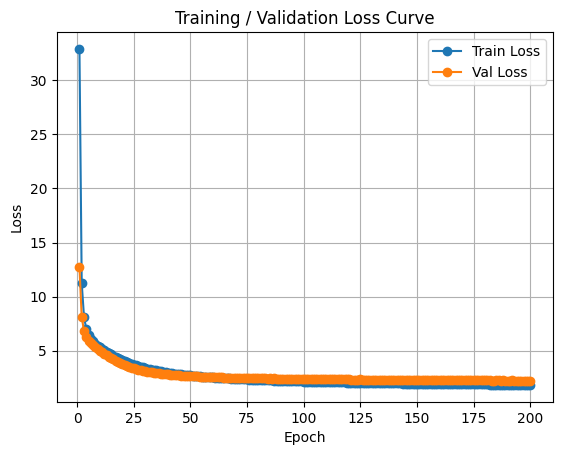

In [47]:
# ============================================================
# [STEP 6 - CELL 4] Visualization: Train/Val Loss Curve (+ optional LR)
# - ✅ 기존 스타일(마커, 그리드)로 러닝 커브 복원
# ============================================================

# 1) Loss curves (Train vs Val)
plt.figure()
plt.plot(range(1, len(train_losses) + 1), train_losses, marker='o', label="Train Loss")
plt.plot(range(1, len(val_losses) + 1), val_losses, marker='o', label="Val Loss")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("Training / Validation Loss Curve")
plt.grid(True)
plt.legend()
plt.show()

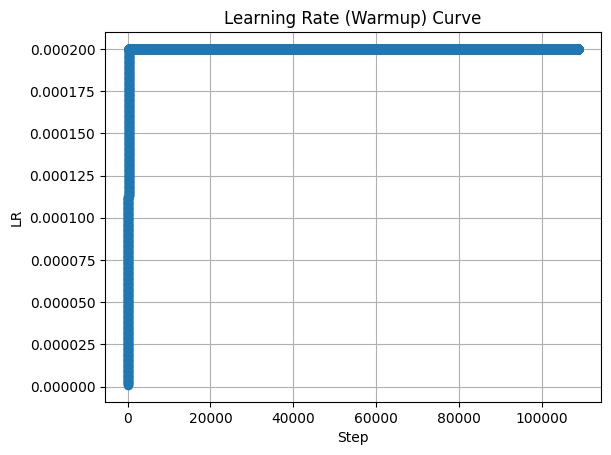

In [48]:
# 2) (선택) LR warmup 확인용
# - 원치 않으면 이 블록 주석 처리하세요.
if len(lr_history) > 0:
    plt.figure()
    plt.plot(range(1, len(lr_history) + 1), lr_history, marker='o')
    plt.xlabel("Step")
    plt.ylabel("LR")
    plt.title("Learning Rate (Warmup) Curve")
    plt.grid(True)
    plt.show()

In [53]:
# 추가 100번 더 
EPOCHS = 100
es = EarlyStopping(patience=10, min_delta=1e-4)

train_losses = []
val_losses = []
lr_history = []  # ✅ 가시화/디버깅용

for epoch in range(1, EPOCHS + 1):
    # --- train ---
    model.train()
    total_loss = 0.0
    global global_step

    for src, tgt in train_dataloader:
        src = src.to(device)
        tgt = tgt.to(device)

        # warmup lr scale
        global_step += 1
        scale = lr_scale(global_step, WARMUP_STEPS)
        for pg in optimizer.param_groups:
            pg["lr"] = float(LR) * scale
        lr_history.append(optimizer.param_groups[0]["lr"])

        loss = train_step(src, tgt, model, optimizer)
        total_loss += float(loss.item())

    avg_train = total_loss / max(len(train_dataloader), 1)
    train_losses.append(avg_train)

    # --- val ---
    model.eval()
    vloss = 0.0
    with torch.no_grad():
        for src, tgt in val_dataloader:
            src = src.to(device)
            tgt = tgt.to(device)
            loss = eval_step(src, tgt, model)
            vloss += float(loss.item())

    avg_val = vloss / max(len(val_dataloader), 1)
    val_losses.append(avg_val)

    print(f"Epoch {epoch:02d} | train_loss={avg_train:.4f} | val_loss={avg_val:.4f} | lr={optimizer.param_groups[0]['lr']:.6f}")

    # early stopping check (val 기준)
    should_stop = es.step(avg_val, model, epoch=epoch)
    if should_stop:
        print(f"EarlyStopping triggered @ epoch {epoch:02d}. best_val={es.best:.4f} (best_epoch={es.best_epoch})")
        break

# best 복원
es.restore(model, device)
print(f"✅ Best model restored (by val_loss). best_val={es.best:.4f} (best_epoch={es.best_epoch})")

Epoch 01 | train_loss=1.8416 | val_loss=2.2370 | lr=0.000200
Epoch 02 | train_loss=1.8433 | val_loss=2.2384 | lr=0.000200
Epoch 03 | train_loss=1.8412 | val_loss=2.2340 | lr=0.000200
Epoch 04 | train_loss=1.8400 | val_loss=2.2281 | lr=0.000200
Epoch 05 | train_loss=1.8371 | val_loss=2.2305 | lr=0.000200
Epoch 06 | train_loss=1.8360 | val_loss=2.2355 | lr=0.000200
Epoch 07 | train_loss=1.8353 | val_loss=2.2346 | lr=0.000200
Epoch 08 | train_loss=1.8332 | val_loss=2.2312 | lr=0.000200
Epoch 09 | train_loss=1.8313 | val_loss=2.2323 | lr=0.000200
Epoch 10 | train_loss=1.8303 | val_loss=2.2291 | lr=0.000200
Epoch 11 | train_loss=1.8287 | val_loss=2.2324 | lr=0.000200
Epoch 12 | train_loss=1.8254 | val_loss=2.2219 | lr=0.000200
Epoch 13 | train_loss=1.8241 | val_loss=2.2289 | lr=0.000200
Epoch 14 | train_loss=1.8213 | val_loss=2.2240 | lr=0.000200
Epoch 15 | train_loss=1.8220 | val_loss=2.2261 | lr=0.000200
Epoch 16 | train_loss=1.8213 | val_loss=2.2308 | lr=0.000200
Epoch 17 | train_loss=1.

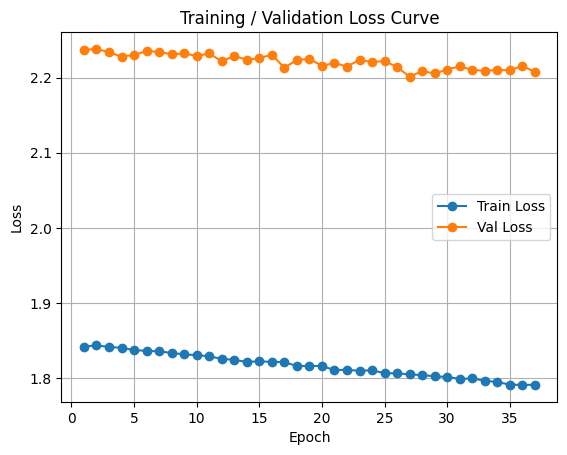

In [54]:
# ============================================================
# [STEP 6 - CELL 4] Visualization: Train/Val Loss Curve (+ optional LR)
# - ✅ 기존 스타일(마커, 그리드)로 러닝 커브 복원
# ============================================================

# 1) Loss curves (Train vs Val)
plt.figure()
plt.plot(range(1, len(train_losses) + 1), train_losses, marker='o', label="Train Loss")
plt.plot(range(1, len(val_losses) + 1), val_losses, marker='o', label="Val Loss")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("Training / Validation Loss Curve")
plt.grid(True)
plt.legend()
plt.show()

In [57]:
# ============================================================
# [STEP 6 - CELL 5] translate() - SPM 디코딩 기반 (함수명 유지)
# - id2token 사용 금지 (SPM이라 없음)
# - Step5의 encode()/pad_to_maxlen()을 그대로 사용 (이름 유지)
# ============================================================

import torch
import torch.nn.functional as F

def _apply_repetition_penalty(logits, generated_ids, penalty=1.25):
    if penalty is None or penalty <= 1.0:
        return logits
    for tid in set(generated_ids):
        logits[tid] /= penalty
    return logits

def _ban_repeat_ngram(logits, generated_ids, n=4):
    if n is None or n <= 1 or len(generated_ids) < (n - 1):
        return logits
    prefix = tuple(generated_ids[-(n-1):])
    banned = set()
    for i in range(len(generated_ids) - (n - 1)):
        if tuple(generated_ids[i:i+(n-1)]) == prefix:
            banned.add(generated_ids[i+(n-1)])
    if banned:
        logits[list(banned)] = -1e9
    return logits

@torch.no_grad()
def translate(tokens, model, max_len=MAX_LEN,
              temperature=0.7,
              top_k=20,
              repetition_penalty=1.25,
              no_repeat_ngram_size=4,
              min_len=3):
    model.eval()

    # Step5 encode/pad_to_maxlen 그대로 사용 (이름 유지)
    src_ids = pad_to_maxlen(encode(tokens), MAX_LEN)
    src = torch.tensor([src_ids], dtype=torch.long, device=device)

    ys = torch.tensor([[BOS_ID]], dtype=torch.long, device=device)

    for _ in range(max_len - 1):
        enc_mask, dec_enc_mask, dec_mask = generate_masks(src, ys)

        logits = model(src, ys,
                       enc_mask.to(device),
                       dec_enc_mask.to(device),
                       dec_mask.to(device))  # (1,T,V)

        next_logits = logits[0, -1, :].clone()

        if ys.size(1) < min_len:
            next_logits[EOS_ID] = -1e9

        gen_ids = ys[0].tolist()
        next_logits = _apply_repetition_penalty(next_logits, gen_ids, penalty=repetition_penalty)
        next_logits = _ban_repeat_ngram(next_logits, gen_ids, n=no_repeat_ngram_size)

        next_logits = next_logits / max(temperature, 1e-6)

        if top_k is not None and top_k > 0:
            topv, topi = torch.topk(next_logits, k=min(top_k, next_logits.size(-1)))
            probs = F.softmax(topv, dim=-1)
            next_id = topi[torch.multinomial(probs, 1)].item()
        else:
            probs = F.softmax(next_logits, dim=-1)
            next_id = torch.multinomial(probs, 1).item()

        ys = torch.cat([ys, torch.tensor([[next_id]], dtype=torch.long, device=device)], dim=1)

        if next_id == EOS_ID:
            break

    # ✅ SPM 디코딩: BOS 제외, EOS 이후 제거
    pred_ids = ys.squeeze(0).tolist()[1:]  # drop BOS
    if EOS_ID in pred_ids:
        pred_ids = pred_ids[:pred_ids.index(EOS_ID)]

    # SPM piece -> string
    # (주의) pred_ids에 PAD/BOS/EOS가 섞이면 제거
    pred_ids = [i for i in pred_ids if i not in (PAD_ID, BOS_ID, EOS_ID)]
    out_text = sp.decode_ids(pred_ids)

    return out_text

In [59]:
# ============================================================
# [STEP 6 - CELL 6] Run examples (전처리/형태소가 없으면 "그대로 토큰화"로 대체)
# ============================================================

examples = [
    "지루하다, 놀러가고 싶어.",
    "오늘 일찍 일어났더니 피곤하다.",
    "간만에 여자친구랑 데이트 하기로 했어.",
    "집에 있는다는 소리야.",
]

# preprocess_sentence/morphs가 없다면, 최소 안전 대체
def _fallback_tokens(s):
    # 아주 단순: 공백 기준
    return s.strip().split()

for s in examples:
    try:
        s_clean = preprocess_sentence(s)
        s_tokens = morphs(s_clean)
    except Exception:
        s_tokens = _fallback_tokens(s)

    out_text = translate(s_tokens, model)
    print("\nQ:", s)
    print("A:", out_text)


Q: 지루하다, 놀러가고 싶어.
A: 저 도 데려가 주세요 .

Q: 오늘 일찍 일어났더니 피곤하다.
A: 그럴 수 있을 거 예요 .

Q: 간만에 여자친구랑 데이트 하기로 했어.
A: 좋은 곳 이 죠 .

Q: 집에 있는다는 소리야.
A: 포커페이스 를 만들어 보아 요 .


### Step 7. 성능 측정 — calculate_bleu() 적용 (이름 유지)
- 이전 노트북에 calculate_bleu()가 이미 있으니 이름은 그대로 유지하되,
- 여기서는 우리 토큰 형식(list[str])에 맞게 작동하는 버전으로 정의함

In [61]:
# ============================================================
# [STEP 7 - CELL 1 - FIXED] Metrics: calculate_bleu() + calculate_rouge()
# - token list 기준 (List[List[str]])
# ✅ 렉 방지 핵심:
#   1) ROUGE-L 기본 OFF (compute_rouge_l=False)
#   2) ROUGE-L 켤 때도 1D DP로 메모리 폭발 방지 + 길이 제한(rouge_l_max_len)
#   3) 필요 시 샘플 수 제한(max_eval)
# ============================================================

import numpy as np

# -----------------------------
# BLEU (Corpus BLEU, 간단 구현)
# -----------------------------
def calculate_bleu(references, hypotheses, max_n=4, smooth=1e-9):
    """
    references: List[List[str]]
    hypotheses: List[List[str]]
    """
    def ngram_counts(tokens, n):
        from collections import Counter
        return Counter([tuple(tokens[i:i+n]) for i in range(len(tokens)-n+1)])

    precisions = []
    for n in range(1, max_n+1):
        match = 0
        total = 0
        for ref, hyp in zip(references, hypotheses):
            ref_cnt = ngram_counts(ref, n)
            hyp_cnt = ngram_counts(hyp, n)
            total += sum(hyp_cnt.values())
            for g, c in hyp_cnt.items():
                match += min(c, ref_cnt.get(g, 0))
        precisions.append((match + smooth) / (total + smooth))

    ref_len = sum(len(r) for r in references)
    hyp_len = sum(len(h) for h in hypotheses)
    if hyp_len == 0:
        return 0.0

    bp = 1.0 if hyp_len > ref_len else np.exp(1 - ref_len / max(hyp_len, 1))
    bleu = bp * np.exp(np.mean(np.log(precisions)))
    return float(bleu)

# -----------------------------
# ROUGE-1/2 (ngram overlap)
# -----------------------------
def _ngram_counts(tokens, n):
    from collections import Counter
    return Counter([tuple(tokens[i:i+n]) for i in range(len(tokens)-n+1)])

def _rouge_n(ref, hyp, n=1):
    ref_ngrams = _ngram_counts(ref, n)
    hyp_ngrams = _ngram_counts(hyp, n)
    overlap = sum((ref_ngrams & hyp_ngrams).values())

    ref_total = sum(ref_ngrams.values())
    hyp_total = sum(hyp_ngrams.values())

    recall = overlap / ref_total if ref_total > 0 else 0.0
    precision = overlap / hyp_total if hyp_total > 0 else 0.0
    f1 = (2*precision*recall/(precision+recall)) if (precision+recall) > 0 else 0.0
    return precision, recall, f1

# -----------------------------
# ROUGE-L (LCS) - 렉 방지 버전
# - 2D dp 테이블을 만들지 않고 1D dp로 메모리 절약
# - 그래도 시간 O(m*n)이므로 길이 제한(rouge_l_max_len)으로 폭발 방지
# -----------------------------
def _lcs_length_1d(a, b):
    """
    a, b: List[str]
    returns: LCS length
    메모리 O(min(len(a), len(b))) 1D DP
    """
    # 항상 b를 더 짧게 만들어 dp 길이를 줄임
    if len(a) < len(b):
        a, b = b, a
    # b가 짧음
    n = len(b)
    dp = [0] * (n + 1)
    for ai in a:
        prev = 0
        for j in range(1, n + 1):
            tmp = dp[j]
            if ai == b[j - 1]:
                dp[j] = prev + 1
            else:
                dp[j] = max(dp[j], dp[j - 1])
            prev = tmp
    return dp[n]

def _rouge_l(ref, hyp):
    lcs = _lcs_length_1d(ref, hyp)
    recall = lcs / len(ref) if len(ref) > 0 else 0.0
    precision = lcs / len(hyp) if len(hyp) > 0 else 0.0
    f1 = (2*precision*recall/(precision+recall)) if (precision+recall) > 0 else 0.0
    return precision, recall, f1

def calculate_rouge(
    references,
    hypotheses,
    compute_rouge_l=False,     # ✅ 기본 OFF (렉 방지)
    rouge_l_max_len=120,       # ✅ ref/hyp 토큰 길이가 이보다 길면 ROUGE-L 스킵
    max_eval=None              # ✅ 필요하면 샘플 수 제한(예: 500)
):
    """
    references/hypotheses: List[List[str]]
    compute_rouge_l=False 를 권장합니다(ROUGE-L은 느림).
    rouge_l_max_len: 토큰이 길면 LCS가 폭발하므로 길이 제한.
    max_eval: 평가 샘플 수 제한(디버그/빠른 확인용).
    """
    # 샘플 제한
    if max_eval is not None:
        references = references[:max_eval]
        hypotheses = hypotheses[:max_eval]

    r1_p=r1_r=r1_f=0.0
    r2_p=r2_r=r2_f=0.0
    rl_p=rl_r=rl_f=0.0
    rl_cnt = 0  # rougeL을 실제로 계산한 샘플 수
    N = max(len(hypotheses), 1)

    for ref, hyp in zip(references, hypotheses):
        p,r,f = _rouge_n(ref, hyp, n=1); r1_p+=p; r1_r+=r; r1_f+=f
        p,r,f = _rouge_n(ref, hyp, n=2); r2_p+=p; r2_r+=r; r2_f+=f

        if compute_rouge_l:
            # 길이 제한: 너무 긴 토큰은 ROUGE-L 스킵(렉 방지)
            if (len(ref) <= rouge_l_max_len) and (len(hyp) <= rouge_l_max_len):
                p,r,f = _rouge_l(ref, hyp); rl_p+=p; rl_r+=r; rl_f+=f
                rl_cnt += 1

    out = {
        "rouge1": {"P": r1_p/N, "R": r1_r/N, "F1": r1_f/N},
        "rouge2": {"P": r2_p/N, "R": r2_r/N, "F1": r2_f/N},
    }

    # rougeL은 켠 경우에만 반환(그리고 스킵이 있을 수 있음)
    if compute_rouge_l:
        denom = max(rl_cnt, 1)
        out["rougeL"] = {"P": rl_p/denom, "R": rl_r/denom, "F1": rl_f/denom}
        out["rougeL_meta"] = {"computed": rl_cnt, "skipped": N - rl_cnt, "max_len": rouge_l_max_len}

    return out

In [63]:
# ============================================================
# [STEP 7 - CELL 2 - FIXED] Evaluate (BLEU + ROUGE)  ✅ 복붙용
# - SPM 파이프라인 호환
# - pred_text(str)을 SPM piece로 다시 토큰화 후 평가
# - ROUGE-L 렉 방지 옵션 포함
# ============================================================

# ✅ 평가 샘플 수 (너무 느리면 줄이세요)
N_EVAL = 2000

# ✅ 증강 데이터 기준 평가
eval_ques = aug_que_corpus[:N_EVAL]
eval_ans  = aug_ans_corpus[:N_EVAL]

def strip_special_tokens(toks):
    specials = {BOS_TOKEN, EOS_TOKEN, PAD_TOKEN, UNK_TOKEN}
    return [t for t in toks if t not in specials]

def _to_token_list_pred(pred, sp):
    """
    pred: translate() 결과 (str 또는 List[str])
    """
    if isinstance(pred, str):
        return sp.encode_as_pieces(pred)
    elif isinstance(pred, (list, tuple)):
        return list(pred)
    else:
        return []

# -----------------------------
# SPM processor 확인
# -----------------------------
try:
    sp
except NameError:
    raise NameError(
        "SPM processor 변수 `sp`가 필요합니다.\n"
        "예: sp = spm.SentencePieceProcessor(); sp.load('xxx.model')"
    )

references, hypotheses = [], []

for q_tokens, a_tokens in zip(eval_ques, eval_ans):

    pred = translate(q_tokens, model)

    # 정답 토큰
    ref_tokens = strip_special_tokens(a_tokens)

    # 예측 토큰
    hyp_tokens = strip_special_tokens(_to_token_list_pred(pred, sp))

    references.append(ref_tokens)
    hypotheses.append(hyp_tokens)

# -----------------------------
# BLEU
# -----------------------------
bleu = calculate_bleu(references, hypotheses)

# -----------------------------
# ROUGE (렉 방지 옵션)
# -----------------------------
rouge = calculate_rouge(
    references,
    hypotheses,
    compute_rouge_l=False,   # 🚨 True로 바꾸면 ROUGE-L 계산
    rouge_l_max_len=120,     # 긴 문장은 LCS 계산 스킵
    max_eval=N_EVAL          # 평가 샘플 제한
)

# -----------------------------
# 출력
# -----------------------------
print(f"BLEU (N={len(hypotheses)}): {bleu:.4f}")

print("ROUGE-1  P/R/F1:", rouge["rouge1"])
print("ROUGE-2  P/R/F1:", rouge["rouge2"])

# ROUGE-L은 옵션이라 존재할 때만 출력
if "rougeL" in rouge:
    print("ROUGE-L  P/R/F1:", rouge["rougeL"])

BLEU (N=2000): 0.0000
ROUGE-1  P/R/F1: {'P': 0.0, 'R': 0.0, 'F1': 0.0}
ROUGE-2  P/R/F1: {'P': 0.0, 'R': 0.0, 'F1': 0.0}


In [78]:
# ============================================================
# [STEP 7 - CELL 2 - FIXED v2] Evaluate (BLEU + ROUGE)  ✅ 복붙용
# - ref/hyp를 "SPM ids(int)"로 통일하여 BLEU/ROUGE 0 고정 문제 해결
# ============================================================

N_EVAL = 2000

eval_ques = aug_que_corpus[:N_EVAL]
eval_ans  = aug_ans_corpus[:N_EVAL]

# ---- special ids (Step5에서 정의돼 있어야 함) ----
SPECIAL_IDS = {PAD_ID, BOS_ID, EOS_ID}
# UNK_ID가 있으면 추가 (없으면 무시)
try:
    SPECIAL_IDS.add(UNK_ID)
except NameError:
    pass

def strip_special_ids(ids):
    return [int(i) for i in ids if int(i) not in SPECIAL_IDS]

def to_ids_ref(a_tokens, sp):
    """
    a_tokens가 어떤 형태든(ref) 최종적으로 SPM ids(list[int])로 변환
    - case1) a_tokens가 이미 ids(int) 리스트인 경우
    - case2) a_tokens가 piece(str) 리스트인 경우
    - case3) a_tokens가 텍스트(str)인 경우
    """
    if isinstance(a_tokens, str):
        return sp.encode_as_ids(a_tokens)

    if isinstance(a_tokens, (list, tuple)) and len(a_tokens) > 0:
        # 이미 int ids?
        if isinstance(a_tokens[0], (int, np.integer)):
            return list(map(int, a_tokens))
        # piece tokens(str)?
        if isinstance(a_tokens[0], str):
            return [sp.piece_to_id(t) for t in a_tokens]

    return []

def to_ids_hyp(pred, sp):
    """
    pred(translate 결과)가 str이면 -> ids
    pred가 list면 -> (str pieces 또는 int ids) 처리
    """
    if isinstance(pred, str):
        return sp.encode_as_ids(pred)

    if isinstance(pred, (list, tuple)) and len(pred) > 0:
        if isinstance(pred[0], (int, np.integer)):
            return list(map(int, pred))
        if isinstance(pred[0], str):
            return [sp.piece_to_id(t) for t in pred]

    return []

# ---- SPM processor 확인 ----
try:
    sp
except NameError:
    raise NameError("SPM processor 변수 `sp`가 필요합니다. (Step5에서 준비되어 있어야 함)")

references, hypotheses = [], []

for q_tokens, a_tokens in zip(eval_ques, eval_ans):
    pred = translate(q_tokens, model)  # 보통 str

    ref_ids = strip_special_ids(to_ids_ref(a_tokens, sp))
    hyp_ids = strip_special_ids(to_ids_hyp(pred, sp))

    references.append(ref_ids)
    hypotheses.append(hyp_ids)

bleu = calculate_bleu(references, hypotheses)
rouge = calculate_rouge(references, hypotheses)

print(f"BLEU (N={len(hypotheses)}): {bleu:.4f}")
print("ROUGE-1  P/R/F1:", rouge["rouge1"])
print("ROUGE-2  P/R/F1:", rouge["rouge2"])

if "rougeL" in rouge:
    print("ROUGE-L  P/R/F1:", rouge["rougeL"])
else:
    print("ROUGE-L  : (not computed / skipped)")

BLEU (N=2000): 0.0000
ROUGE-1  P/R/F1: {'P': 0.0, 'R': 0.0, 'F1': 0.0}
ROUGE-2  P/R/F1: {'P': 0.0, 'R': 0.0, 'F1': 0.0}
ROUGE-L  : (not computed / skipped)


In [79]:
# ============================================================
# [DEBUG] eval_ques / eval_ans 타입/샘플 확인 
# ============================================================

def _peek(x, n=10):
    if isinstance(x, (list, tuple)):
        return x[:n]
    return x

print("type(eval_ques[0]) =", type(eval_ques[0]))
print("type(eval_ans[0])  =", type(eval_ans[0]))

q0 = eval_ques[0]
a0 = eval_ans[0]

print("\n[Q0] elem type =", type(q0[0]) if isinstance(q0, (list,tuple)) and len(q0)>0 else None)
print("[Q0] head      =", _peek(q0, 15))

print("\n[A0] elem type =", type(a0[0]) if isinstance(a0, (list,tuple)) and len(a0)>0 else None)
print("[A0] head      =", _peek(a0, 15))

# ref/hyp 길이 분포에서 "빈 것"이 많은지 확인
empty_q = sum(1 for q in eval_ques if (not q) or (isinstance(q,(list,tuple)) and len(q)==0))
empty_a = sum(1 for a in eval_ans  if (not a) or (isinstance(a,(list,tuple)) and len(a)==0))
print("\nempty questions:", empty_q, "/", len(eval_ques))
print("empty answers  :", empty_a, "/", len(eval_ans))

type(eval_ques[0]) = <class 'list'>
type(eval_ans[0])  = <class 'list'>

[Q0] elem type = <class 'str'>
[Q0] head      = ['12시', '땡', '!']

[A0] elem type = <class 'str'>
[A0] head      = ['하루', '가', '또', '가네요', '.']

empty questions: 0 / 2000
empty answers  : 0 / 2000


In [82]:
# ============================================================
# [STEP 7 - CELL 2 - FIXED v2] Evaluate (BLEU + ROUGE) ✅ SPM piece 공간 통일
# - ref(정답)도 "문자열로 합친 뒤" SPM piece로 토큰화
# - hyp(예측)도 SPM piece로 토큰화
# - rougeL 키 에러 방지 출력 포함
# ============================================================

N_EVAL = 2000

eval_ques = aug_que_corpus[:N_EVAL]
eval_ans  = aug_ans_corpus[:N_EVAL]

def strip_special_tokens(toks):
    specials = {BOS_TOKEN, EOS_TOKEN, PAD_TOKEN, UNK_TOKEN}
    return [t for t in toks if t not in specials]

def to_spm_pieces_from_tokens(tokens, sp):
    """
    tokens: List[str] (형태소/단어 토큰)
    -> 문자열로 합친 후 SPM piece 토큰화
    """
    if tokens is None:
        return []
    if isinstance(tokens, (list, tuple)):
        text = " ".join(tokens).strip()
    else:
        text = str(tokens).strip()
    if not text:
        return []
    return sp.encode_as_pieces(text)

def to_spm_pieces_from_pred(pred, sp):
    """
    pred: translate() 결과 (str 또는 List[str])
    """
    if isinstance(pred, str):
        return sp.encode_as_pieces(pred)
    elif isinstance(pred, (list, tuple)):
        # 이미 token list로 오는 경우도 문자열로 합쳐 SPM piece로 통일
        text = " ".join(map(str, pred)).strip()
        return sp.encode_as_pieces(text) if text else []
    else:
        return []

# SPM processor 확인
try:
    sp
except NameError:
    raise NameError("SPM processor 변수 `sp`가 필요합니다. (Step5에서 준비되어 있어야 함)")

references, hypotheses = [], []

for q_tokens, a_tokens in zip(eval_ques, eval_ans):
    pred = translate(q_tokens, model)  # str

    # 1) 정답: (형태소/단어 토큰) -> SPM piece로 변환
    ref_tokens = strip_special_tokens(a_tokens)
    ref_pieces = to_spm_pieces_from_tokens(ref_tokens, sp)

    # 2) 예측: (문자열) -> SPM piece로 변환
    hyp_pieces = to_spm_pieces_from_pred(pred, sp)
    hyp_pieces = strip_special_tokens(hyp_pieces)

    references.append(ref_pieces)
    hypotheses.append(hyp_pieces)

bleu = calculate_bleu(references, hypotheses)
rouge = calculate_rouge(references, hypotheses)

print(f"BLEU (N={len(hypotheses)}): {bleu:.4f}")
print("ROUGE-1  P/R/F1:", rouge["rouge1"])
print("ROUGE-2  P/R/F1:", rouge["rouge2"])
if "rougeL" in rouge:
    print("ROUGE-L  P/R/F1:", rouge["rougeL"])
else:
    print("ROUGE-L  : (not computed / skipped)")

BLEU (N=2000): 0.7771
ROUGE-1  P/R/F1: {'P': 0.8846237289993287, 'R': 0.8812912580711345, 'F1': 0.8818886208827382}
ROUGE-2  P/R/F1: {'P': 0.7915292428331914, 'R': 0.7874332703996223, 'F1': 0.7884962408200293}
ROUGE-L  : (not computed / skipped)


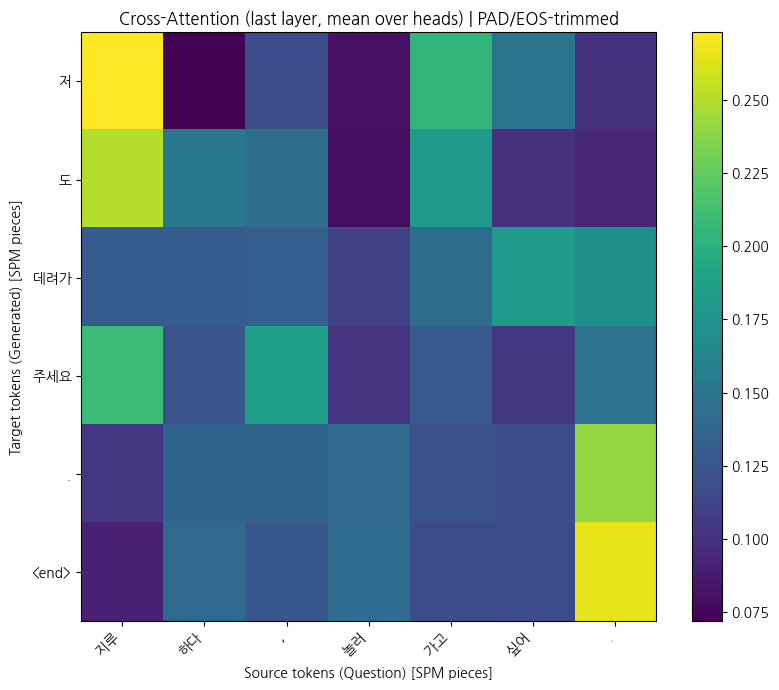

In [70]:
# ============================================================
# [STEP 7 - CELL 3 - FIXED] Attention Map (Cross-Attention)  ✅ SPM 호환
# - 함수명 plot_cross_attention 유지
# - token2id/id2token 제거 (SPM id 기반)
# - translate()가 str을 반환해도 OK: pred_text -> SPM ids로 복원
# - PAD/EOS 길이 정확 슬라이싱
# - preprocess_sentence/morphs 없으면 fallback
# ============================================================

import os
import numpy as np
import torch
import matplotlib.pyplot as plt
import matplotlib.font_manager as fm

import matplotlib.pyplot as plt
import matplotlib.font_manager as fm

# 한글은 NanumGothic, 없는 글리프(▁ 등)는 DejaVu Sans가 대신 렌더링
plt.rcParams["font.family"] = ["NanumGothic", "DejaVu Sans"]
plt.rcParams["axes.unicode_minus"] = False

def _setup_korean_font():
    candidates = [
        "C:/Windows/Fonts/NanumGothic.ttf",
        "C:/Windows/Fonts/nanumgothic.ttf",
        "C:/Windows/Fonts/malgun.ttf",
        "/usr/share/fonts/truetype/nanum/NanumGothic.ttf",
        "/usr/share/fonts/truetype/nanum/NanumBarunGothic.ttf",
    ]
    for p in candidates:
        if os.path.exists(p):
            fp = fm.FontProperties(fname=p)
            plt.rcParams["font.family"] = fp.get_name()
            plt.rcParams["axes.unicode_minus"] = False
            return
    plt.rcParams["axes.unicode_minus"] = False

_setup_korean_font()

# -----------------------------
# helpers
# -----------------------------
def _len_until_pad_id(ids, pad_id=PAD_ID):
    ids = list(ids)
    try:
        return ids.index(pad_id)
    except ValueError:
        return len(ids)

def _len_until_eos_id(ids, eos_id=EOS_ID):
    ids = list(ids)
    try:
        return ids.index(eos_id) + 1
    except ValueError:
        return len(ids)

def _ids_to_pieces(ids, sp):
    # SPM의 ▁(공백표시)를 사람이 읽기 좋게 공백으로 치환
    return [sp.id_to_piece(int(i)).replace("▁", " ") for i in ids]

def _fallback_tokens(s: str):
    return s.strip().split()

def plot_cross_attention(question_text, drop_bos=True):
    """
    question_text: str
    drop_bos: True이면 타겟축(BOS) 제거하여 보기 좋게 표시
    """
    model.eval()

    # -----------------------------
    # 0) SPM processor 확인
    # -----------------------------
    try:
        sp
    except NameError:
        raise NameError("SPM processor 변수 `sp`가 필요합니다. (Step5에서 준비되어 있어야 함)")

    # -----------------------------
    # 1) 질문 -> 토큰 (기존 파이프라인 유지 + fallback)
    # -----------------------------
    try:
        q_clean = preprocess_sentence(question_text)
    except Exception:
        q_clean = question_text

    try:
        q_tokens = morphs(q_clean)  # list[str]
    except Exception:
        q_tokens = _fallback_tokens(q_clean)

    # -----------------------------
    # 2) 질문 토큰 -> SPM ids (Step5 encode/pad_to_maxlen 유지)
    # -----------------------------
    src_ids = pad_to_maxlen(encode(q_tokens), MAX_LEN)  # List[int]
    src = torch.tensor([src_ids], dtype=torch.long, device=device)

    # -----------------------------
    # 3) translate() 실행 (현재 구현: str 반환)
    # -----------------------------
    pred = translate(q_tokens, model)

    # -----------------------------
    # 4) 예측을 디코더 입력 ids로 복원 (BOS + pred_ids + EOS)
    # -----------------------------
    if isinstance(pred, str):
        pred_ids = sp.encode_as_ids(pred)
    elif isinstance(pred, (list, tuple)):
        # pred가 piece 토큰 리스트면 piece->id, id 리스트면 int로 캐스팅
        pred_ids = []
        for t in pred:
            if isinstance(t, str):
                pred_ids.append(sp.piece_to_id(t))
            else:
                pred_ids.append(int(t))
    else:
        pred_ids = []

    ys_ids = [BOS_ID] + pred_ids

    # EOS 보장(없으면 추가)
    if (len(ys_ids) < MAX_LEN) and (EOS_ID not in ys_ids):
        ys_ids.append(EOS_ID)

    ys_ids = ys_ids[:MAX_LEN]
    ys = torch.tensor([ys_ids], dtype=torch.long, device=device)

    # -----------------------------
    # 5) attention 캡처용 forward 1회
    # -----------------------------
    enc_mask, dec_enc_mask, dec_mask = generate_masks(src, ys)
    with torch.no_grad():
        _ = model(src, ys,
                  enc_mask.to(device),
                  dec_enc_mask.to(device),
                  dec_mask.to(device))

    attn = getattr(model, "last_cross_attn", None)
    if attn is None:
        print("No attention captured. (model.last_cross_attn is None)")
        print("→ Step6 pack의 DecoderLayer/Transformer에 last_cross_attn 저장이 있는지 확인")
        return

    # attn: (B,h,Tt,Ts) -> (h,Tt,Ts)
    attn = attn[0].detach().cpu().numpy()
    attn_mean = attn.mean(axis=0)  # (Tt,Ts)

    # -----------------------------
    # 6) PAD/EOS 기준 슬라이싱 길이
    # -----------------------------
    src_len = _len_until_pad_id(src_ids, PAD_ID)
    tgt_len = _len_until_eos_id(ys_ids, EOS_ID)

    # -----------------------------
    # 7) 축 라벨: SPM piece 기준
    # -----------------------------
    src_show = _ids_to_pieces(src_ids[:src_len], sp)
    tgt_show = _ids_to_pieces(ys_ids[:tgt_len], sp)

    attn_show = attn_mean[:tgt_len, :src_len]

    # 보기 좋게 BOS 제거 옵션
    if drop_bos and len(tgt_show) > 0 and ys_ids[0] == BOS_ID:
        tgt_show = tgt_show[1:]
        attn_show = attn_show[1:, :]

    # -----------------------------
    # 8) Plot
    # -----------------------------
    fig_w = min(12, 0.6 * len(src_show) + 4)
    fig_h = min(10, 0.5 * len(tgt_show) + 4)

    plt.figure(figsize=(fig_w, fig_h))
    plt.imshow(attn_show, aspect="auto")
    plt.xticks(range(len(src_show)), src_show, rotation=45, ha="right")
    plt.yticks(range(len(tgt_show)), tgt_show)
    plt.xlabel("Source tokens (Question) [SPM pieces]")
    plt.ylabel("Target tokens (Generated) [SPM pieces]")
    plt.title("Cross-Attention (last layer, mean over heads) | PAD/EOS-trimmed")
    plt.colorbar()
    plt.tight_layout()
    plt.show()

# 예시
plot_cross_attention("지루하다, 놀러가고 싶어.")

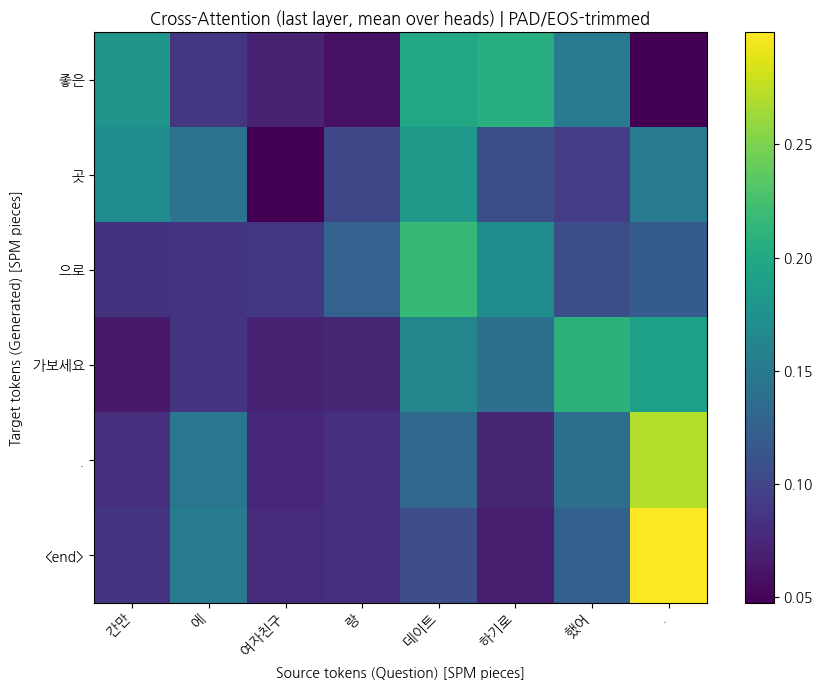

In [72]:
plot_cross_attention("간만에 여자친구랑 데이트 하기로 했어.")

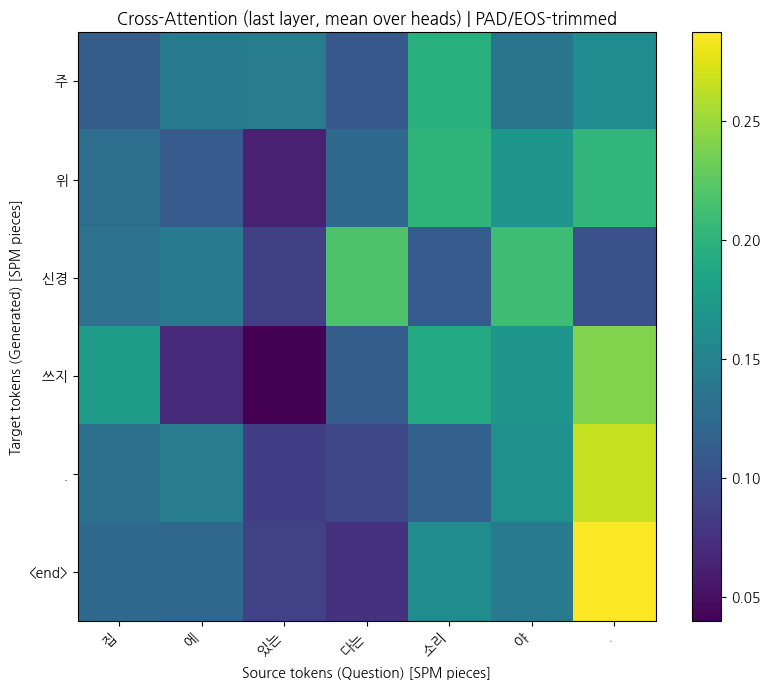

In [74]:
plot_cross_attention("집에 있는다는 소리야.")